In [1]:
# %pip install ipywidgets

In [2]:
import os

# Disable the C-linker to avoid the relocation/linkage error.
# This will use the Python backend. For 1-property sampling, 
# the performance hit is negligible.
os.environ["PYTENSOR_FLAGS"] = "cxx=,linker=py"

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the generated dataset
df = pd.read_csv("../data/london_rentals_fix_params.csv")

# --- 1. DEFINING THE "TRUTH" (From your generation script) ---
INTERCEPT = 7.5
BETA_ROOM = 0.15
BETA_DIST = -0.05
BETA_UNDERGROUND = 0.10
SIGMA = 0.1  # The market noise/volatility
AGENT_PREMIUM = 0.15

# Mappings for categorical logic
TYPE_MAP = {'House': 0.2, 'Flat': 0.0}
OUTDOOR_MAP = {'Garden': 0.15, 'Terrace': 0.1, 'Balcony': 0.05, 'Nothing': 0.0}

# --- 2. FEATURE ENGINEERING ---
# We transform everything into log-space because the math is additive there.
df['log_rent'] = np.log(df['monthly_rent_gbp'])

# Calculate the "Intrinsic Value" of the property (everything except the Agent markup)
# This is our mu (mean) for the 'Owner' hypothesis.
df['expected_log_rent_base'] = (
    INTERCEPT + 
    (df['n_rooms'] * BETA_ROOM) +
    (df['dist_centre_km'] * BETA_DIST) +
    (df['near_underground'] * BETA_UNDERGROUND) +
    df['property_type'].map(TYPE_MAP) +
    df['outdoor_space'].map(OUTDOOR_MAP)
)

print(f"Dataset loaded. Total properties: {len(df)}")
print(f"Reference Sigma: {SIGMA} (approx {SIGMA*100}% price fluctuation)")
df[['monthly_rent_gbp', 'log_rent', 'expected_log_rent_base']].head()

Dataset loaded. Total properties: 1000
Reference Sigma: 0.1 (approx 10.0% price fluctuation)


,monthly_rent_gbp,log_rent,expected_log_rent_base
0,3102.955547,8.040110,7.990439
1,3157.070671,8.057400,8.071226
2,3667.633778,8.207302,8.142533
3,4132.482893,8.326634,8.174331
4,1771.819406,7.479762,7.503178


In [3]:
# --- BAYESIAN LIKELIHOOD CALCULATION ---

"""
LOGIC:
Our generative model defined price as: 
    ln(Price) = expected_log_rent + Noise(0, sigma^2)

To perform inference, we calculate the 'Likelihood'—the probability of observing 
the actual rent given a specific hypothesis (Owner vs. Agent). 

MATH:
If the noise is Gaussian, the likelihood follows the Normal PDF:
    P(Data | Hypothesis) = (1 / (σ * sqrt(2π))) * exp(-0.5 * ((x - μ) / σ)^2)

Where:
    x = The observed 'log_rent'
    μ = Our calculated 'expected_log_rent_base' (plus premium if Agent)
    σ = The 'SIGMA' (0.1) representing market volatility
"""

# Hypothesis A: The property is an Owner listing (No Premium)
# Here, μ = expected_log_rent_base
df['likelihood_owner'] = stats.norm.pdf(
    df['log_rent'], 
    loc=df['expected_log_rent_base'], 
    scale=SIGMA
)

# Hypothesis B: The property is an Agent listing (Includes +0.15 Premium)
# Here, μ = expected_log_rent_base + 0.15
df['likelihood_agent'] = stats.norm.pdf(
    df['log_rent'], 
    loc=df['expected_log_rent_base'] + AGENT_PREMIUM, 
    scale=SIGMA
)

# Preview the results
print("Likelihoods calculated based on Normal PDF of residuals.")
df[['monthly_rent_gbp', 'listing_type', 'likelihood_owner', 'likelihood_agent']].head()

Likelihoods calculated based on Normal PDF of residuals.


,monthly_rent_gbp,listing_type,likelihood_owner,likelihood_agent
0,3102.955547,Owner,3.526423,2.411756
1,3157.070671,Owner,3.951472,1.042573
2,3667.633778,Owner,3.234571,2.774385
3,4132.482893,Owner,1.250867,3.988365
4,1771.819406,Owner,3.881543,0.886923


In [4]:
# --- MODEL COMPARISON: POSTERIOR ODDS RATIO ---

# 1. Calculate the Bayes Factor (Likelihood Ratio)
# How much better does the Agent model explain the price than the Owner model?
df['bayes_factor'] = df['likelihood_agent'] / df['likelihood_owner']

# 2. Prior Odds (0.5 / 0.5 = 1)
prior_odds = 1.0

# 3. Posterior Odds Ratio
df['posterior_odds'] = df['bayes_factor'] * prior_odds

# 4. Decision Logic
# Ratio > 1 -> Evidence favors Agent
# Ratio < 1 -> Evidence favors Owner
print("Odds Ratios calculated. Evidence check:")
df[['monthly_rent_gbp', 'listing_type', 'bayes_factor', 'posterior_odds']].head(10)

Odds Ratios calculated. Evidence check:


,monthly_rent_gbp,listing_type,bayes_factor,posterior_odds
0,3102.955547,Owner,0.683910,0.683910
1,3157.070671,Owner,0.263844,0.263844
2,3667.633778,Owner,0.857729,0.857729
3,4132.482893,Owner,3.188481,3.188481
4,1771.819406,Owner,0.228497,0.228497
5,4523.793073,Owner,0.228503,0.228503
6,3011.560738,Owner,3.468836,3.468836
7,3277.097326,Owner,1.026497,1.026497
8,1665.001388,Owner,0.160540,0.160540
9,3251.304470,Owner,0.732597,0.732597


In [5]:
# --- ACCURACY EVALUATION ---

# 1. The Decision: Pick the model with the higher odds
df['predicted_type'] = np.where(df['posterior_odds'] > 1, 'Agent', 'Owner')

# 2. Check if the prediction matches the ground truth
df['is_correct'] = df['predicted_type'] == df['listing_type']

# 3. Calculate overall accuracy percentage
accuracy = df['is_correct'].mean() * 100

print(f"--- Model Accuracy: {accuracy:.2f}% ---")

# 4. Breakdown by class (Confusion Matrix)
print("\nPrediction Breakdown:")
print(pd.crosstab(df['listing_type'], df['predicted_type']))

--- Model Accuracy: 78.20% ---

Prediction Breakdown:
predicted_type  Agent  Owner
listing_type                
Agent             391    109
Owner             109    391


We now consider the more complicated case where the parameters in the likelihood are free to vary.

In [6]:
import pymc as pm  # This is our MCMC sampler
import arviz as az # For visualizing posterior distributions

# Load the NEW dataset with random parameters
df = pd.read_csv("../data/london_rentals_rand_params.csv")

# --- 1. SETTING OUR HYPER-PRIORS ---
# These reflect the means of the distributions we used in gen_prop_data.py
# In a real-world scenario, these would be based on historical market data.
VOLATILITY = 0.03  # Our 'Market Volatility' from the generation script

# Mappings for categorical logic (used to prepare the data for PyMC)
df['is_house'] = df['property_type'].map({'House': 1, 'Flat': 0})
df['has_garden'] = (df['outdoor_space'] == 'Garden').astype(int)
df['has_terrace'] = (df['outdoor_space'] == 'Terrace').astype(int)
df['has_balcony'] = (df['outdoor_space'] == 'Balcony').astype(int)

# --- 2. FEATURE ENGINEERING ---
df['log_rent'] = np.log(df['monthly_rent_gbp'])

# We still calculate a 'baseline' expected rent using the means for comparison,
# but the MCMC model will treat these coefficients as flexible distributions.
# Reference means from our non-Gaussian generation script
INTERCEPT_MU = 7.5
ROOM_MU      = 0.15
DIST_MU      = -0.05
UNDER_MU     = 0.10
HOUSE_MU     = 0.20
GARDEN_MU    = 0.15
TERRACE_MU   = 0.10
BALCONY_MU   = 0.05

df['expected_log_rent_fixed_ref'] = (
    INTERCEPT_MU + 
    (df['n_rooms'] * ROOM_MU) + 
    (df['dist_centre_km'] * DIST_MU) + 
    (df['near_underground'] * UNDER_MU) +
    (df['is_house'] * HOUSE_MU) +
    (df['has_garden'] * GARDEN_MU) +
    (df['has_terrace'] * TERRACE_MU) +
    (df['has_balcony'] * BALCONY_MU)
)

print(f"Dataset loaded: {len(df)} properties.")
print(f"Likelihood assumption: Agent premium follows a Gamma distribution.")
print(f"Likelihood assumption: Room value follows a Laplace distribution.")
df[['monthly_rent_gbp', 'log_rent', 'expected_log_rent_fixed_ref']].head()

Dataset loaded: 1000 properties.
Likelihood assumption: Agent premium follows a Gamma distribution.
Likelihood assumption: Room value follows a Laplace distribution.


,monthly_rent_gbp,log_rent,expected_log_rent_fixed_ref
0,3482.235341,8.155430,7.990439
1,3448.296661,8.145636,8.071226
2,5188.841209,8.554266,8.142533
3,5241.364385,8.564337,8.174331
4,2119.278223,7.658831,7.503178


In [9]:
# 1. SELECT THE TEST PROPERTY
# We pick one property from our dataset to perform the 'Injection Test'
idx = 0  # Change this index to test different properties
test_prop = df.iloc[idx]
y_obs = test_prop['log_rent']

print(f"Testing Property ID: {test_prop.get('id', idx)}")
print(f"Observed Log Price: {y_obs:.4f}")
print(f"True Listing Type: {test_prop['listing_type']}")
print("-" * 30)

def run_model_selection(y, prop_data, mc_draws=100, is_agent_hyp=False):
    """
    Computes the Log-Evidence (log Z) for a specific hypothesis using SMC.
    Optimized to only include relevant structural parameters.
    """
    
    with pm.Model() as model:
        # --- PRIORS: Based on our injection distributions ---
        vol = 0.03
        
        # Market intercept and slopes (Gaussian)
        intercept = pm.Normal("intercept", mu=7.5, sigma=vol)
        beta_dist = pm.Normal("beta_dist", mu=-0.05, sigma=vol)
        
        # Room impact (Laplace - fat-tailed)
        beta_room = pm.Laplace("beta_room", mu=0.15, b=vol)
        
        # --- CONDITIONAL STRUCTURAL PRIORS ---
        # Initialize the linear predictor with baseline features
        mu = (
            intercept +
            (prop_data['n_rooms'] * beta_room) +
            (prop_data['dist_centre_km'] * beta_dist)
        )

        # Only define beta_under if the property is near an underground station
        if prop_data['near_underground'] == '1':
            beta_under = pm.Normal("beta_under", mu=0.10, sigma=vol)
            mu += beta_under

        # Only define beta_house if it's a House
        if prop_data['property_type'] == 'House':
            beta_house = pm.Normal("beta_house", mu=0.20, sigma=vol)
            mu += beta_house
            
        # Only define the specific outdoor prior for the feature present
        outdoor = prop_data['outdoor_space']
        if outdoor == 'Garden':
            beta_garden = pm.Normal("beta_garden", mu=0.15, sigma=vol)
            mu += beta_garden
        elif outdoor == 'Terrace':
            beta_terrace = pm.Normal("beta_terrace", mu=0.10, sigma=vol)
            mu += beta_terrace
        elif outdoor == 'Balcony':
            beta_balcony = pm.Normal("beta_balcony", mu=0.05, sigma=vol)
            mu += beta_balcony
        
        # --- AGENT PREMIUM LOGIC ---
        if is_agent_hyp:
            premium = pm.Gamma("premium", alpha=5.0, beta=5.0/0.15)
            mu += premium
        
        # --- LIKELIHOOD ---
        pm.StudentT("obs", nu=5, mu=mu, sigma=0.1, observed=y)
        
        # --- MARGINAL LIKELIHOOD ESTIMATION ---
        trace = pm.sample_smc(
            draws=mc_draws, 
            chains=4, 
            progressbar=True,
            return_inferencedata=True,
        )
        
        return trace

# 2. COMPUTE LOG-EVIDENCE FOR BOTH MODELS
# In PyMC 5, Log Z is stored in the sample_stats of the first chain
# We take the mean across chains if multiple chains are used
mc_draws = 1000
print("Calculating Evidence for Owner Model...")
owner = run_model_selection(y_obs, test_prop, mc_draws=mc_draws, is_agent_hyp=False)
log_z_owner = owner.sample_stats.log_marginal_likelihood.mean().item()

print("Calculating Evidence for Agent Model...")
agent = run_model_selection(y_obs, test_prop, mc_draws=mc_draws, is_agent_hyp=True)
log_z_agent = agent.sample_stats.log_marginal_likelihood.mean().item()

# 3. INTERPRETATION
log_BF = log_z_agent - log_z_owner
BF = np.exp(log_BF)

print("\n--- RESULTS ---")
print(f"Log Z (Owner): {log_z_owner:.4f}")
print(f"Log Z (Agent): {log_z_agent:.4f}")
print(f"Bayes Factor (K): {BF:.4f}")

if BF > 10:
    print("Conclusion: Strong Evidence for AGENT model.")
elif BF < 0.1:
    print("Conclusion: Strong Evidence for OWNER model.")
else:
    print("Conclusion: Ambiguous Evidence (Inconclusive).")

Initializing SMC sampler...


Testing Property ID: 0
Observed Log Price: 8.1554
True Listing Type: Owner
------------------------------
Calculating Evidence for Owner Model...


Sampling 4 chains sequentially


Output()

/usr/local/python/3.12.1/lib/python3.12/site-packages/arviz/data/base.py:272: UserWarning: More chains (4) than draws (1). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
Initializing SMC sampler...
Sampling 4 chains sequentially


Output()


--- RESULTS ---
Log Z (Owner): 0.3116
Log Z (Agent): 0.6441
Bayes Factor (K): 1.3945
Conclusion: Ambiguous Evidence (Inconclusive).


/usr/local/python/3.12.1/lib/python3.12/site-packages/arviz/data/base.py:272: UserWarning: More chains (4) than draws (1). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


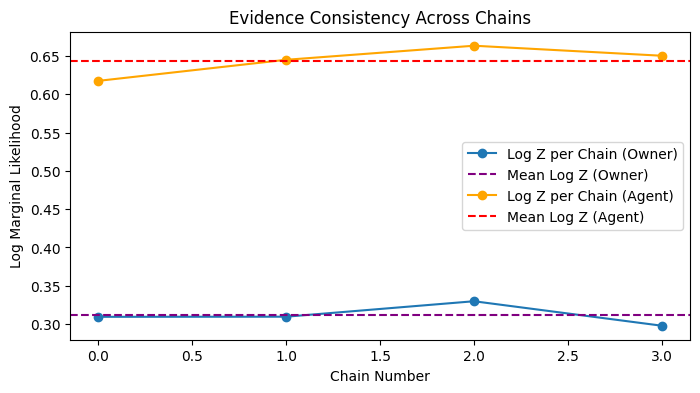

In [10]:
# Access the log_marginal_likelihood per chain
# This shows if all 4 chains reached roughly the same conclusion
log_z_per_chain_owner = owner.sample_stats.log_marginal_likelihood.values
log_z_per_chain_agent = agent.sample_stats.log_marginal_likelihood.values

plt.figure(figsize=(8, 4))
plt.plot(log_z_per_chain_owner, 'o-', label='Log Z per Chain (Owner)')
plt.axhline(log_z_per_chain_owner.mean(), color='purple', linestyle='--', label='Mean Log Z (Owner)')
plt.plot(log_z_per_chain_agent, 'o-', color='orange', label='Log Z per Chain (Agent)')
plt.axhline(log_z_per_chain_agent.mean(), color='r', linestyle='--', label='Mean Log Z (Agent)')
plt.xlabel('Chain Number')
plt.ylabel('Log Marginal Likelihood')
plt.title('Evidence Consistency Across Chains')
plt.legend()
plt.show()

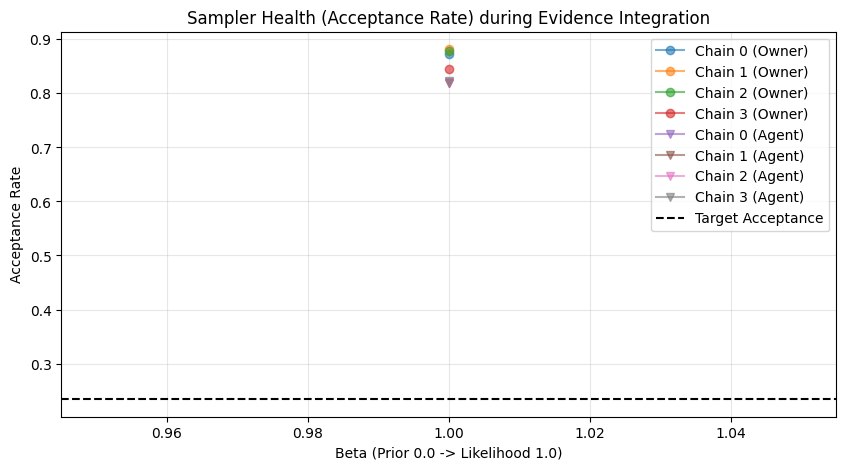

In [11]:
# Accessing the available variables from your KeyError list
accept_rates_owner = owner.sample_stats["accept_rate"].values
betas_owner = owner.sample_stats["beta"].values
accept_rates_agent = agent.sample_stats["accept_rate"].values
betas_agent = agent.sample_stats["beta"].values

plt.figure(figsize=(10, 5))

# Plotting the acceptance rate across stages
# Note: In SMC, 'draw' index usually corresponds to the stage index here
for i in range(accept_rates_owner.shape[0]):
    plt.plot(betas_owner[i], accept_rates_owner[i], 'o-', alpha=0.6, label=f'Chain {i} (Owner)')
for i in range(accept_rates_agent.shape[0]):
    plt.plot(betas_agent[i], accept_rates_agent[i], 'v-', alpha=0.6, label=f'Chain {i} (Agent)')
plt.axhline(y=0.234, color='k', linestyle='--', label='Target Acceptance')
plt.xlabel('Beta (Prior 0.0 -> Likelihood 1.0)')
plt.ylabel('Acceptance Rate')
plt.title('Sampler Health (Acceptance Rate) during Evidence Integration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

OWNER



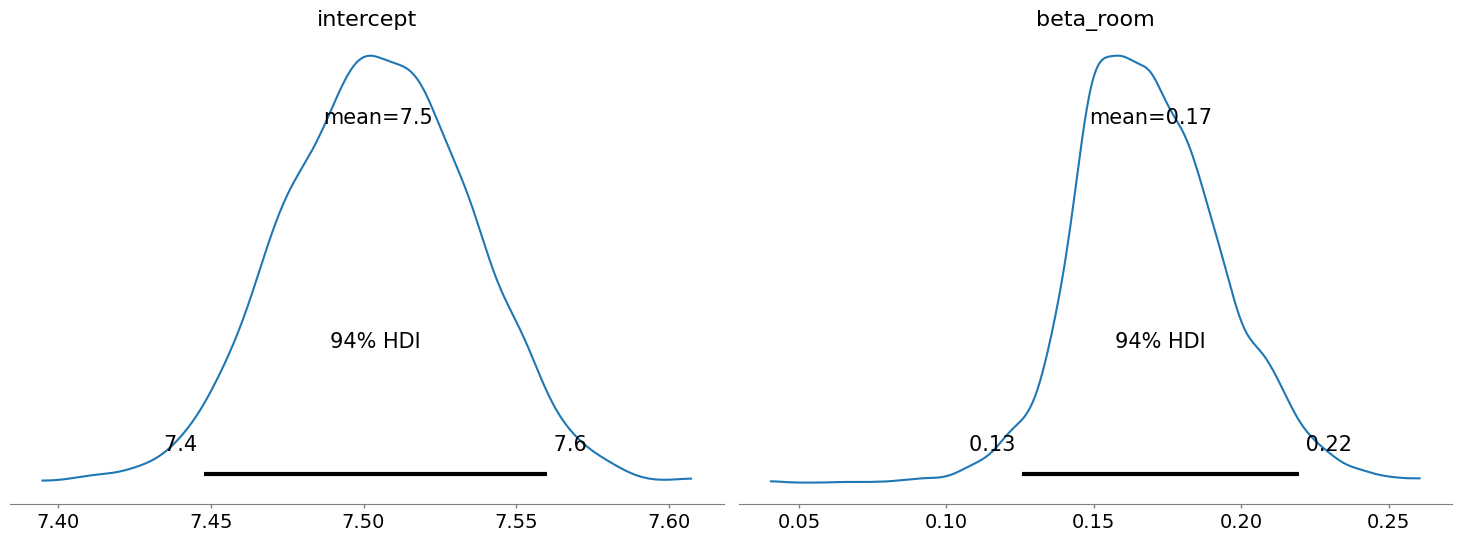

AGENT



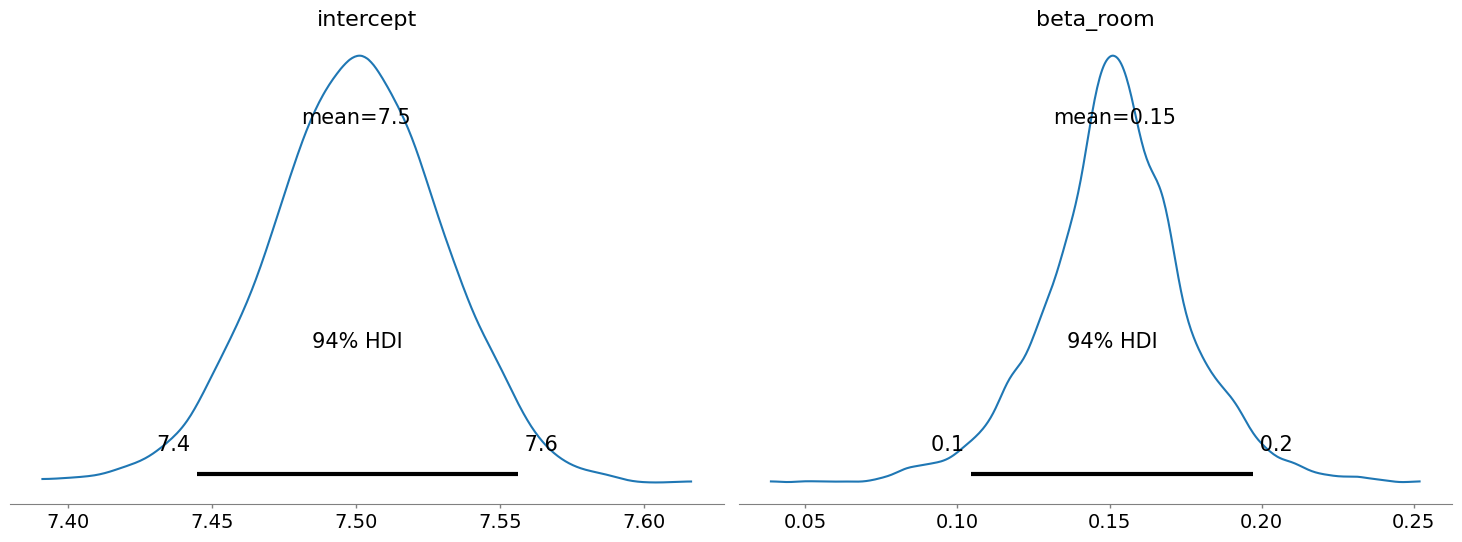

In [12]:
# Plot the distribution of the parameters after seeing the data
print("OWNER")
print("")
az.plot_posterior(owner, var_names=['intercept', 'beta_room'])
plt.tight_layout()
plt.show()

print("AGENT")
print("")
az.plot_posterior(agent, var_names=['intercept', 'beta_room'])
plt.tight_layout()
plt.show()

Sampling: [obs]


Output()

Sampling: [obs]


Output()

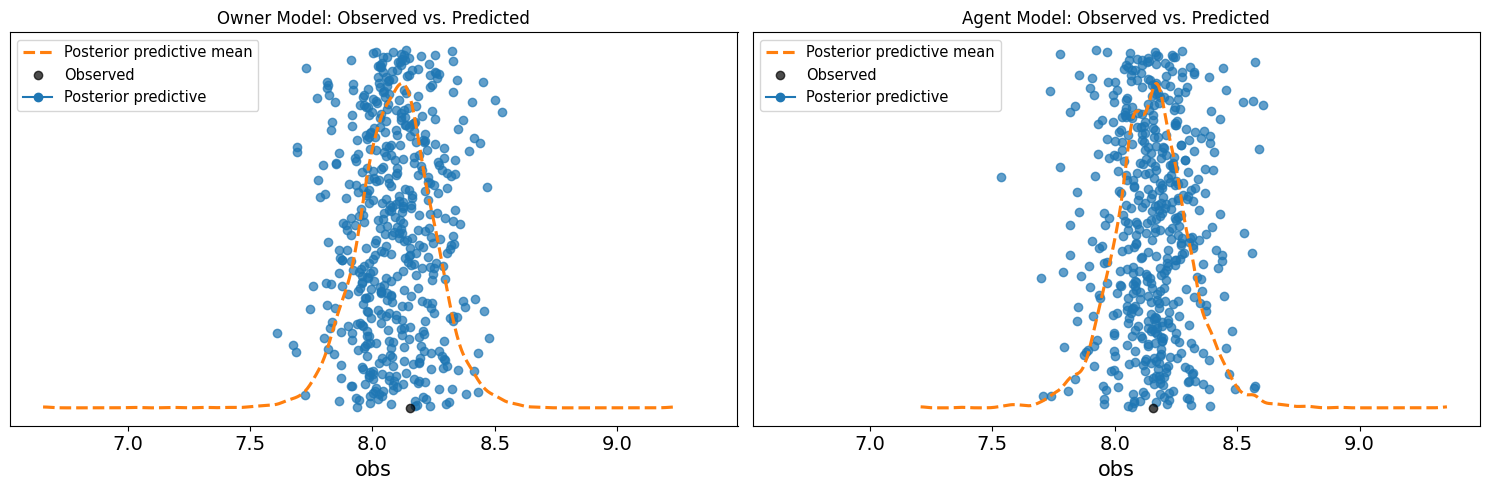

In [13]:
# --- POSTERIOR PREDICTIVE CHECK (OWNER) ---
with pm.Model() as owner_model:
    vol = 0.03
    
    # Standard Market Priors
    intercept = pm.Normal("intercept", mu=7.5, sigma=vol)
    beta_dist = pm.Normal("beta_dist", mu=-0.05, sigma=vol)
    beta_room = pm.Laplace("beta_room", mu=0.15, b=vol)
    
    # Start the linear predictor
    mu = (intercept + 
          (test_prop['n_rooms'] * beta_room) + 
          (test_prop['dist_centre_km'] * beta_dist))
    
    # Conditional Structural Features
    if test_prop['near_underground'] == 1:
        beta_under = pm.Normal("beta_under", mu=0.10, sigma=vol)
        mu += beta_under

    if test_prop['property_type'] == 'House':
        beta_house = pm.Normal("beta_house", mu=0.20, sigma=vol)
        mu += beta_house
        
    outdoor = test_prop['outdoor_space']
    if outdoor == 'Garden':
        beta_garden = pm.Normal("beta_garden", mu=0.15, sigma=vol)
        mu += beta_garden
    elif outdoor == 'Terrace':
        beta_terrace = pm.Normal("beta_terrace", mu=0.10, sigma=vol)
        mu += beta_terrace
    elif outdoor == 'Balcony':
        beta_balcony = pm.Normal("beta_balcony", mu=0.05, sigma=vol)
        mu += beta_balcony
    
    pm.StudentT("obs", nu=5, mu=mu, sigma=0.1, observed=y_obs)
    
    # We sample the predictive distribution using the 'owner' trace calculated earlier
    pm.sample_posterior_predictive(owner, extend_inferencedata=True)

# --- POSTERIOR PREDICTIVE CHECK (AGENT) ---
with pm.Model() as agent_model:
    vol = 0.03
    
    intercept = pm.Normal("intercept", mu=7.5, sigma=vol)
    beta_dist = pm.Normal("beta_dist", mu=-0.05, sigma=vol)
    beta_room = pm.Laplace("beta_room", mu=0.15, b=vol)
    
    # Agent hypothesis includes the premium
    premium = pm.Gamma("premium", alpha=5.0, beta=5.0/0.15)
    
    mu = (intercept + 
          (test_prop['n_rooms'] * beta_room) + 
          (test_prop['dist_centre_km'] * beta_dist) + 
          premium)
    
    # Conditional Structural Features
    if test_prop['near_underground'] == 1:
        beta_under = pm.Normal("beta_under", mu=0.10, sigma=vol)
        mu += beta_under
        
    if test_prop['property_type'] == 'House':
        beta_house = pm.Normal("beta_house", mu=0.20, sigma=vol)
        mu += beta_house
        
    outdoor = test_prop['outdoor_space']
    if outdoor == 'Garden':
        beta_garden = pm.Normal("beta_garden", mu=0.15, sigma=vol)
        mu += beta_garden
    elif outdoor == 'Terrace':
        beta_terrace = pm.Normal("beta_terrace", mu=0.10, sigma=vol)
        mu += beta_terrace
    elif outdoor == 'Balcony':
        beta_balcony = pm.Normal("beta_balcony", mu=0.05, sigma=vol)
        mu += beta_balcony
    
    pm.StudentT("obs", nu=5, mu=mu, sigma=0.1, observed=y_obs)
    
    # We sample the predictive distribution using the 'agent' trace calculated earlier
    pm.sample_posterior_predictive(agent, extend_inferencedata=True)

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Owner
az.plot_ppc(owner, kind="scatter", num_pp_samples=500, ax=axes[0])
axes[0].set_title("Owner Model: Observed vs. Predicted")

# Plot Agent
az.plot_ppc(agent, kind="scatter", num_pp_samples=500, ax=axes[1])
axes[1].set_title("Agent Model: Observed vs. Predicted")

plt.tight_layout()
plt.show()

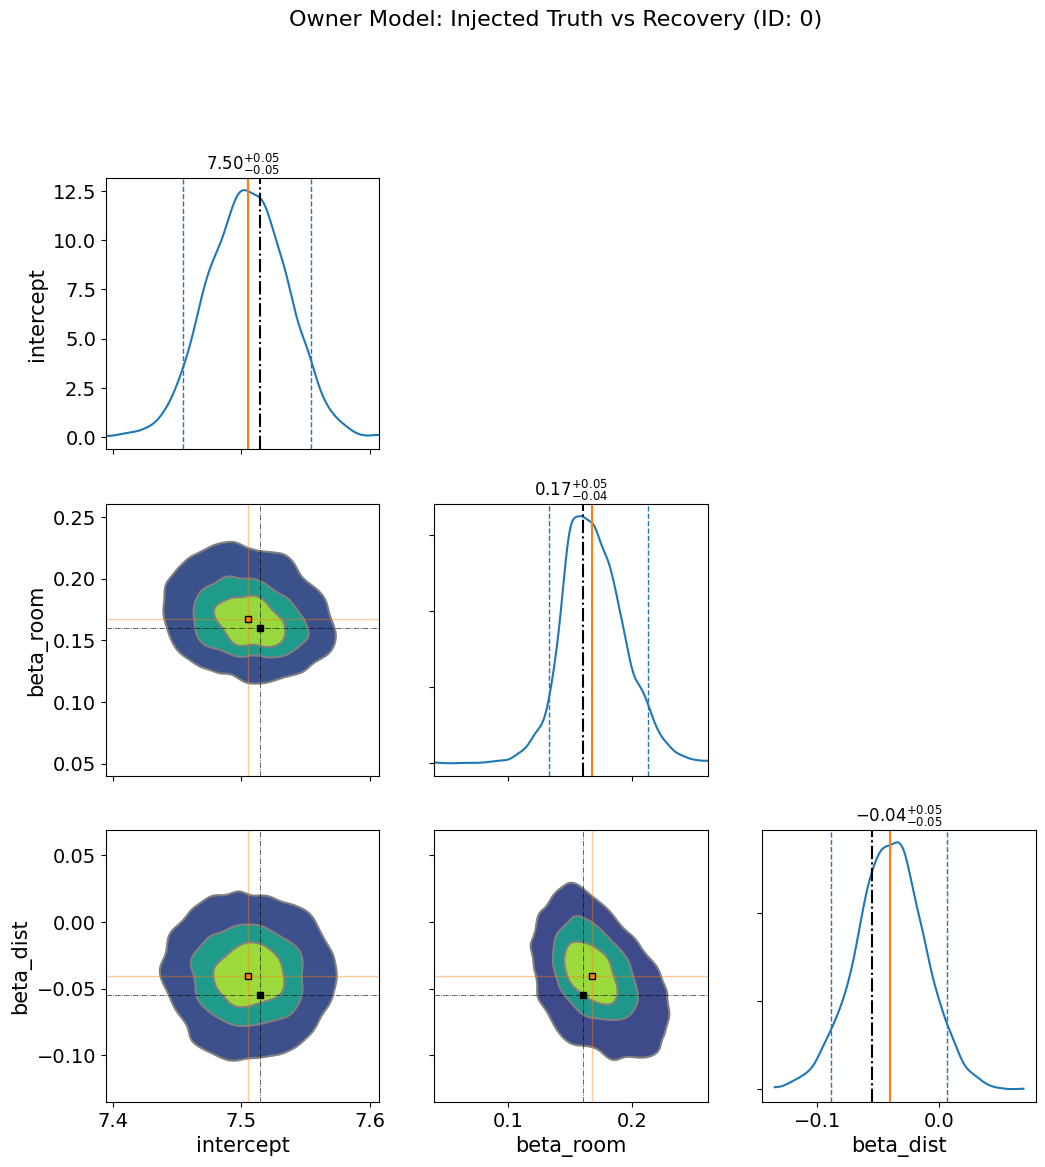

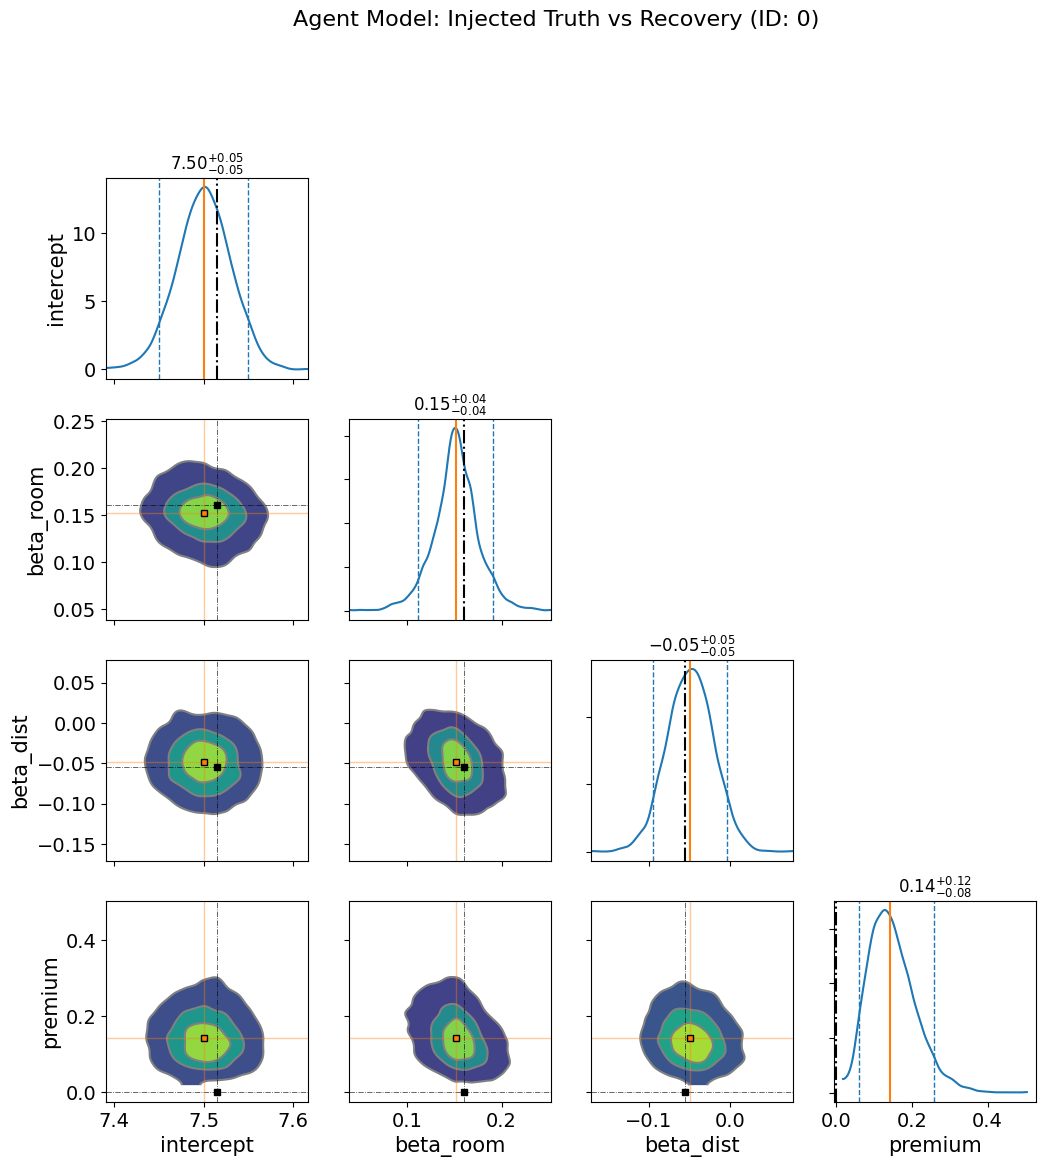

In [14]:
# --- 0. DYNAMIC VARIABLE SELECTION & TRUTH MAPPING ---
base_vars = ["intercept", "beta_room", "beta_dist"]
structural_vars = []

if test_prop['near_underground'] == 1:
    structural_vars.append("beta_under")

if test_prop['property_type'] == 'House':
    structural_vars.append("beta_house")

outdoor = test_prop['outdoor_space']
if outdoor in ['Garden', 'Terrace', 'Balcony']:
    structural_vars.append(f"beta_{outdoor.lower()}")

owner_vars = base_vars + structural_vars
agent_vars = owner_vars + ["premium"]

# Map internal variable names to the specific "true_" columns in the data
# Uses direct access as columns are guaranteed to exist per data generation logic
truth_values = {
    "intercept": test_prop["intercept"],
    "beta_room": test_prop["beta_room"],
    "beta_dist": test_prop["beta_dist"],
    "beta_under": test_prop["beta_under"],
    "beta_house": test_prop["beta_prop"],
    "beta_garden": test_prop["beta_outdoor"],
    "beta_terrace": test_prop["beta_outdoor"],
    "beta_balcony": test_prop["beta_outdoor"],
    "premium": test_prop["premium"]
}

# --- 1. OWNER MODEL CORNER PLOT ---
stats_owner = {v: float(owner.posterior[v].median()) for v in owner_vars}

axes_owner = az.plot_pair(
    owner,
    var_names=owner_vars,
    kind='kde',
    marginals=True,
    reference_values=stats_owner,
    reference_values_kwargs={'color': 'C1', 'marker': 's', 'markersize': 4, 'zorder': 10},
    figsize=(12, 12),
    kde_kwargs={"hdi_probs": [0.3, 0.6, 0.9]}
)

rows, cols = axes_owner.shape
for i in range(rows):
    for j in range(cols):
        ax = axes_owner[i, j]
        if ax is None: continue
        
        var_i = owner_vars[i]
        if i == j:
            # 1D Posterior + Truth Line
            data = owner.posterior[var_i].values.flatten()
            q_low, med, q_high = np.percentile(data, [5, 50, 95])
            ax.axvline(q_low, color='C0', linestyle='--', linewidth=1)
            ax.axvline(q_high, color='C0', linestyle='--', linewidth=1)
            ax.axvline(med, color='C1', linestyle='-', linewidth=1.5)
            # Injected Truth Line (Black Dash-Dot)
            ax.axvline(truth_values[var_i], color='black', linestyle='-.', linewidth=1.5)
            
            upper, lower = q_high - med, med - q_low
            ax.set_title(f"${med:.2f}^{{+{upper:.2f}}}_{{-{lower:.2f}}}$", fontsize=12)
        elif i > j:
            # 2D Posterior
            var_j = owner_vars[j]
            
            # --- Injected Truth Crosshair ---
            ax.axvline(truth_values[var_j], color='black', linestyle='-.', linewidth=0.6, alpha=0.7)
            ax.axhline(truth_values[var_i], color='black', linestyle='-.', linewidth=0.6, alpha=0.7)
            # Truth Square
            ax.plot(truth_values[var_j], truth_values[var_i], 
                    marker='s', color='black', markersize=5, zorder=11)
            
            # --- Median Reference lines (Orange) ---
            ax.axvline(stats_owner[var_j], color='C1', linestyle='-', linewidth=1, alpha=0.4)
            ax.axhline(stats_owner[var_i], color='C1', linestyle='-', linewidth=1, alpha=0.4)

plt.suptitle(f"Owner Model: Injected Truth vs Recovery (ID: {test_prop.get('id', idx)})", fontsize=16, y=1.02)
plt.show()

# --- 2. AGENT MODEL CORNER PLOT ---
stats_agent = {v: float(agent.posterior[v].median()) for v in agent_vars}

axes_agent = az.plot_pair(
    agent,
    var_names=agent_vars,
    kind='kde',
    marginals=True,
    reference_values=stats_agent,
    reference_values_kwargs={'color': 'C1', 'marker': 's', 'markersize': 4, 'zorder': 10},
    figsize=(12, 12),
    kde_kwargs={"hdi_probs": [0.3, 0.6, 0.9]}
)

rows, cols = axes_agent.shape
for i in range(rows):
    for j in range(cols):
        ax = axes_agent[i, j]
        if ax is None: continue
        
        var_i = agent_vars[i]
        if i == j:
            # 1D Posterior + Truth Line
            data = agent.posterior[var_i].values.flatten()
            q_low, med, q_high = np.percentile(data, [5, 50, 95])
            ax.axvline(q_low, color='C0', linestyle='--', linewidth=1)
            ax.axvline(q_high, color='C0', linestyle='--', linewidth=1)
            ax.axvline(med, color='C1', linestyle='-', linewidth=1.5)
            # Injected Truth Line (Black Dash-Dot)
            ax.axvline(truth_values[var_i], color='black', linestyle='-.', linewidth=1.5)
            
            upper, lower = q_high - med, med - q_low
            ax.set_title(f"${med:.2f}^{{+{upper:.2f}}}_{{-{lower:.2f}}}$", fontsize=12)
        elif i > j:
            # 2D Posterior
            var_j = agent_vars[j]
            
            # --- Injected Truth Crosshair ---
            ax.axvline(truth_values[var_j], color='black', linestyle='-.', linewidth=0.6, alpha=0.7)
            ax.axhline(truth_values[var_i], color='black', linestyle='-.', linewidth=0.6, alpha=0.7)
            # Truth Square
            ax.plot(truth_values[var_j], truth_values[var_i], 
                    marker='s', color='black', markersize=5, zorder=11)
            
            # --- Median Reference lines (Orange) ---
            ax.axvline(stats_agent[var_j], color='C1', linestyle='-', linewidth=1, alpha=0.4)
            ax.axhline(stats_agent[var_i], color='C1', linestyle='-', linewidth=1, alpha=0.4)

plt.suptitle(f"Agent Model: Injected Truth vs Recovery (ID: {test_prop.get('id', idx)})", fontsize=16, y=1.02)
plt.show()

In [15]:
# Focus only on the main slopes and intercept
print("OWNER")
print("")
stats = az.summary(owner)
print(stats)
print("")

print("AGENT")
print("")
stats = az.summary(agent)
print(stats)

OWNER

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept  7.505  0.030   7.448    7.560        0.0      0.0    3940.0   
beta_dist -0.041  0.028  -0.096    0.012        0.0      0.0    4208.0   
beta_room  0.169  0.025   0.126    0.219        0.0      0.0    3893.0   

           ess_tail  r_hat  
intercept    3922.0    1.0  
beta_dist    3844.0    1.0  
beta_room    3870.0    1.0  

AGENT

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept  7.500  0.030   7.445    7.556      0.000    0.000    3995.0   
beta_dist -0.049  0.028  -0.101    0.003      0.000    0.000    3907.0   
beta_room  0.152  0.024   0.104    0.197      0.000    0.000    4066.0   
premium    0.149  0.062   0.045    0.264      0.001    0.001    3769.0   

           ess_tail  r_hat  
intercept    3737.0    1.0  
beta_dist    3926.0    1.0  
beta_room    3873.0    1.0  
premium      3662.0    1.0  


In [16]:
# --- 1. PREPARE RESULTS DATASET ---
# Using the truth_values dictionary created in the previous step
results = []

# --- 2. COMPUTE Z-SCORES FOR OWNER MODEL ---
for var in owner_vars:
    post_samples = owner.posterior[var].values.flatten()
    post_median = np.median(post_samples)
    post_sd = np.std(post_samples)
    injected_truth = truth_values[var]
    
    z_score = (post_median - injected_truth) / post_sd
    
    results.append({
        "Model": "Owner",
        "Parameter": var,
        "Injected Truth": injected_truth,
        "Posterior Median": post_median,
        "Posterior SD": post_sd,
        "Z-Score": z_score
    })

# --- 3. COMPUTE Z-SCORES FOR AGENT MODEL ---
for var in agent_vars:
    post_samples = agent.posterior[var].values.flatten()
    post_median = np.median(post_samples)
    post_sd = np.std(post_samples)
    injected_truth = truth_values[var]
    
    z_score = (post_median - injected_truth) / post_sd
    
    results.append({
        "Model": "Agent",
        "Parameter": var,
        "Injected Truth": injected_truth,
        "Posterior Median": post_median,
        "Posterior SD": post_sd,
        "Z-Score": z_score
    })

# --- 4. DISPLAY RESULTS ---
z_score_df = pd.DataFrame(results)

print(f"Recovery Analysis for Property ID: {test_prop.get('id', idx)}")
display(z_score_df.style.format({
    "Injected Truth": "{:.3f}",
    "Posterior Median": "{:.3f}",
    "Posterior SD": "{:.3f}",
    "Z-Score": "{:.2f}"
}).background_gradient(subset=['Z-Score'], cmap='RdYlGn_r', vmin=-3, vmax=3))

# Quick Interpretation
print("\nInterpretation Guide:")
print("- |Z| < 1.0: Excellent recovery (Truth is in the 'inner core').")
print("- 1.0 < |Z| < 2.0: Good recovery (Truth is within 95% of expected area).")
print("- |Z| > 2.0: Potential outlier or model bias for this specific run.")

Recovery Analysis for Property ID: 0


,Model,Parameter,Injected Truth,Posterior Median,Posterior SD,Z-Score
0,Owner,intercept,7.515,7.505,0.030,-0.33
1,Owner,beta_room,0.160,0.168,0.025,0.29
2,Owner,beta_dist,-0.055,-0.040,0.028,0.52
3,Agent,intercept,7.515,7.501,0.030,-0.48
4,Agent,beta_room,0.160,0.152,0.024,-0.35
5,Agent,beta_dist,-0.055,-0.048,0.028,0.23
6,Agent,premium,0.000,0.142,0.062,2.29



Interpretation Guide:
- |Z| < 1.0: Excellent recovery (Truth is in the 'inner core').
- 1.0 < |Z| < 2.0: Good recovery (Truth is within 95% of expected area).
- |Z| > 2.0: Potential outlier or model bias for this specific run.
